<a href="https://colab.research.google.com/github/bsc1990/Cases-FIAP/blob/main/case_olist_fiap_bruno_chagas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd

# Carregar datasets
customers = pd.read_csv('/content/olist_customers_dataset.csv')
geolocation = pd.read_csv('/content/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
category_translation = pd.read_csv('/content/product_category_name_translation.csv')

In [46]:
# CATEGORIA PRODUTO
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)


In [47]:

# BASE PRINCIPAL
# orders + customers
df_raw = orders.merge(
    customers,
    on='customer_id',
    how='left'
)


In [48]:

# ITENS DO PEDIDO (EXPANDE A BASE)
df_raw = df_raw.merge(
    order_items,
    on='order_id',
    how='left'
)


In [49]:

# PRODUTOS
df_raw = df_raw.merge(
    products,
    on='product_id',
    how='left'
)


In [50]:

# SELLERS
df_raw = df_raw.merge(
    sellers,
    on='seller_id',
    how='left',
    suffixes=('', '_seller')
)


In [51]:

# PAYMENTS (SEM AGREGAR)
df_raw = df_raw.merge(
    payments,
    on='order_id',
    how='left'
)


In [52]:

# REVIEWS (SEM AGREGAR)
df_raw = df_raw.merge(
    reviews,
    on='order_id',
    how='left',
    suffixes=('', '_review')
)


In [53]:

# GEOLOCALIZAÇÃO (cliente + seller)

# Criar base única de geolocalização
geo_unique = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# JOIN - CLIENTE
df_raw = df_raw.merge(
    geo_unique,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

df_raw = df_raw.rename(columns={
    'geolocation_lat': 'customer_geolocation_lat',
    'geolocation_lng': 'customer_geolocation_lng',
    'geolocation_city': 'customer_geolocation_city',
    'geolocation_state': 'customer_geolocation_state'
})

df_raw = df_raw.drop(columns=['geolocation_zip_code_prefix'])


# JOIN - SELLER
df_raw = df_raw.merge(
    geo_unique,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

df_raw = df_raw.rename(columns={
    'geolocation_lat': 'seller_geolocation_lat',
    'geolocation_lng': 'seller_geolocation_lng',
    'geolocation_city': 'seller_geolocation_city',
    'geolocation_state': 'seller_geolocation_state'
})

df_raw = df_raw.drop(columns=['geolocation_zip_code_prefix'])


##>>>>>>>>>>> Validação <<<<<<<<<<<<<<

In [54]:
df_raw['order_id'].nunique()

99441

In [55]:
orders['order_id'].nunique()

99441

## >>>>>>>>>>> Tabelas Agrupadas <<<<<<<<<<<<<<

In [56]:
# Tabela Nível Item

df_items_agg = df_raw.groupby([
    'order_id',
    'customer_unique_id',
    'customer_state',
    'seller_id',
    'seller_state',
    'product_category_name_english',
    'order_purchase_timestamp',
    'order_status'
]).agg(

    # Valores
    price_sum=('price', 'sum'),
    freight_sum=('freight_value', 'sum'),
    payment_sum=('payment_value', 'sum'),

    # Qualidade
    review_mean=('review_score', 'mean'),

    # Contagens
    items_count=('order_item_id', 'count'),
    products_count=('product_id', 'nunique')

).reset_index()


__builtins__.print("\n df_items_agg - visão inicial")
display(df_items_agg.head())



 df_items_agg - visão inicial


,order_id,customer_unique_id,customer_state,seller_id,seller_state,product_category_name_english,order_purchase_timestamp,order_status,price_sum,freight_sum,payment_sum,review_mean,items_count,products_count
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,48436dade18ac8b2bce089ec2a041202,SP,cool_stuff,2017-09-13 08:59:02,delivered,58.90,13.29,72.19,5.0,1,1
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,dd7ddc04e1b6c2c614352b383efe2d36,SP,pet_shop,2017-04-26 10:53:06,delivered,239.90,19.93,259.83,4.0,1,1
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,5b51032eddd242adc84c38acab88f23d,MG,furniture_decor,2018-01-14 14:33:31,delivered,199.00,17.87,216.87,5.0,1,1
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,SP,9d7a1d34a5052409006425275ba1c2b4,SP,perfumery,2018-08-08 10:00:35,delivered,12.99,12.79,25.78,4.0,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,SP,df560393f3a51e74553ab94004ba5c87,PR,garden_tools,2017-02-04 13:57:51,delivered,199.90,18.14,218.04,5.0,1,1


In [57]:
# Tabela Nível Pedido

df_orders_agg = df_raw.groupby([
    'order_id',
    'customer_unique_id',
    'customer_state',
    'order_purchase_timestamp',
    'order_status'
]).agg({

    # Receita total
    'price': 'sum',
    'freight_value': 'sum',
    'payment_value': 'sum',

    # Avaliação
    'review_score': 'mean',

    # Contagens
    'order_item_id': 'count',
    'product_id': 'nunique',
    'seller_id': 'nunique'

}).rename(columns={
    'order_item_id': 'items_count',
    'product_id': 'products_count',
    'seller_id': 'sellers_count'
}).reset_index()


__builtins__.print("\n df_orders_agg - visão inicial")
display(df_orders_agg.head())




 df_orders_agg - visão inicial


,order_id,customer_unique_id,customer_state,order_purchase_timestamp,order_status,price,freight_value,payment_value,review_score,items_count,products_count,sellers_count
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,2017-09-13 08:59:02,delivered,58.90,13.29,72.19,5.0,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,2017-04-26 10:53:06,delivered,239.90,19.93,259.83,4.0,1,1,1
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,2018-01-14 14:33:31,delivered,199.00,17.87,216.87,5.0,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,SP,2018-08-08 10:00:35,delivered,12.99,12.79,25.78,4.0,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,SP,2017-02-04 13:57:51,delivered,199.90,18.14,218.04,5.0,1,1,1


In [58]:
# Tabela Nível Cliente

df_customers_agg = df_raw.groupby([
    'customer_unique_id',
    'customer_state'
]).agg({

    # Receita total
    'payment_value': 'sum',

    # Comportamento
    'order_id': 'nunique',
    'product_id': 'nunique',

    # Satisfação
    'review_score': 'mean'

}).rename(columns={
    'order_id': 'orders_count',
    'product_id': 'products_count'
}).reset_index()

__builtins__.print("\n df_customers_agg - visão inicial")
display(df_customers_agg.head())




 df_customers_agg - visão inicial


,customer_unique_id,customer_state,payment_value,orders_count,products_count,review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,141.90,1,1,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,27.19,1,1,4.0
2,0000f46a3911fa3c0805444483337064,SC,86.22,1,1,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,PA,43.62,1,1,4.0
4,0004aac84e0df4da2b147fca70cf8255,SP,196.89,1,1,5.0


##            >>>>>>>>> Analise <<<<<<<<<

In [59]:
# Receita, Pedidos e Ticket Médio por Mês/Ano

df_orders_agg['order_purchase_timestamp'] = pd.to_datetime(df_orders_agg['order_purchase_timestamp'])
df_orders_agg['year_month'] = df_orders_agg['order_purchase_timestamp'].dt.to_period('M')

monthly = df_orders_agg.groupby('year_month').agg({
    'payment_value': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'orders'}).reset_index()
monthly['ticket_medio'] = monthly['payment_value'] / monthly['orders']

display(monthly)

,year_month,payment_value,orders,ticket_medio
0,2016-09,388.47,4,97.117500
1,2016-10,76559.05,324,236.293364
2,2016-12,19.62,1,19.620000
3,2017-01,190806.27,800,238.507837
4,2017-02,351848.13,1780,197.667489
5,2017-03,547769.84,2682,204.239314
6,2017-04,512126.52,2404,213.030998
7,2017-05,737425.31,3700,199.304138
8,2017-06,613777.41,3245,189.145581
9,2017-07,749242.84,4026,186.101053


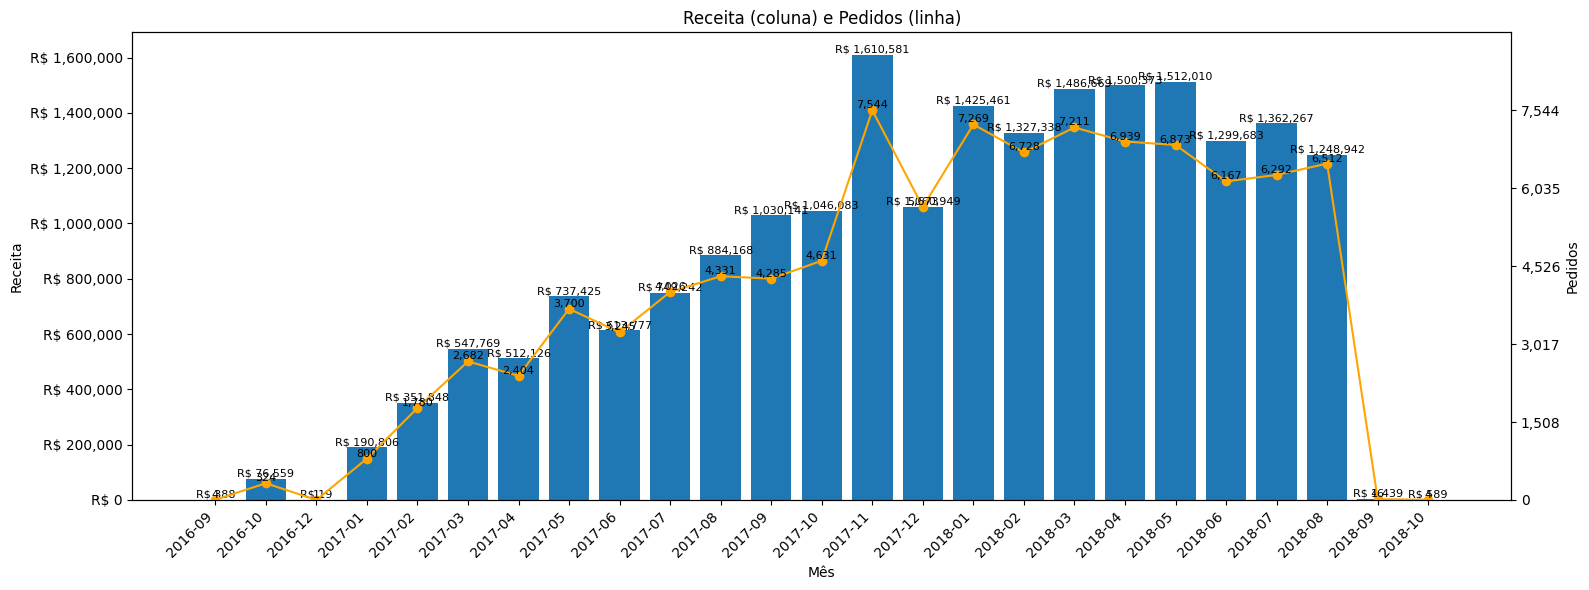

In [60]:
# Gráfico de Receita e Pedidos

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter


# Preparação dos dados
monthly = monthly.sort_values('year_month')
monthly['year_month'] = monthly['year_month'].astype(str)

x = np.arange(len(monthly))


# Criação do gráfico
fig, ax1 = plt.subplots(figsize=(16, 6))


# Receita (barras)
bars = ax1.bar(x, monthly['payment_value'], label='Receita')


# Pedidos (linha - eixo secundário)
ax2 = ax1.twinx()
line = ax2.plot(x, monthly['orders'], marker='o', label='Pedidos', color='orange')


# Títulos
ax1.set_title('Receita (coluna) e Pedidos (linha)')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Receita')
ax2.set_ylabel('Pedidos')


# Eixo X
ax1.set_xticks(x)
ax1.set_xticklabels(monthly['year_month'], rotation=45, ha='right')


# Eixo Y secundário
ax2.set_ylim(0, monthly['orders'].max() * 1.2)
ax2.set_yticks(np.linspace(0, monthly['orders'].max(), 6))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))


# Eixo Y principal (R$)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {int(x):,}'))


# Barras (Receita)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'R$ {int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Linha (Pedidos)
for i, value in enumerate(monthly['orders']):
    ax2.text(
        x[i],
        value,
        f'{int(value):,}',
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

# Layout
plt.tight_layout()
plt.show()

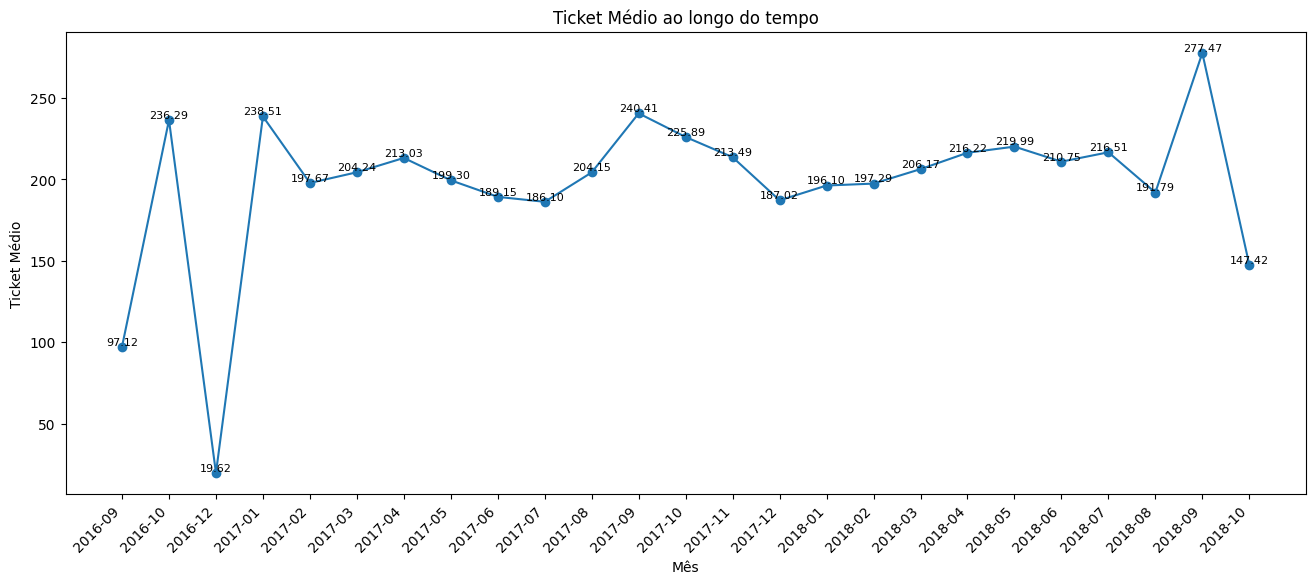

In [61]:
# Gráfico Ticket Médio
plt.figure(figsize=(16, 6))

plt.plot(monthly['year_month'], monthly['ticket_medio'], marker='o')

plt.title('Ticket Médio ao longo do tempo')
plt.xlabel('Mês')
plt.ylabel('Ticket Médio')

plt.xticks(rotation=45, ha='right')

for i, value in enumerate(monthly['ticket_medio']):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

plt.show()

In [62]:
# Receita, Pedidos e Ticket Médio por UF

uf_metrics = df_orders_agg.groupby('customer_state').agg({
    'payment_value': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'orders'}).reset_index()

uf_metrics['ticket_medio'] = (uf_metrics['payment_value'] / uf_metrics['orders']).round(2)

# 5 UFs com maior Receita
print("\nTop 5 UFs com maior Receita:")
display(uf_metrics[['customer_state','payment_value', 'orders', 'ticket_medio']]
        .sort_values(by='payment_value', ascending=False)
        .head(5)
        .reset_index(drop=True))

# 5 UFs com maior número de Pedidos
print("\nTop 5 UFs com maior número de Pedidos:")
display(uf_metrics[['customer_state','payment_value', 'orders', 'ticket_medio']]
        .sort_values(by='orders', ascending=False)
        .head(5)
        .reset_index(drop=True))

# 5 UFs com maior Ticket Médio
print("\nTop 5 UFs com maior Ticket Médio:")
display(uf_metrics[['customer_state','payment_value', 'orders', 'ticket_medio']]
        .sort_values(by='ticket_medio', ascending=False)
        .head(5)
        .reset_index(drop=True))


Top 5 UFs com maior Receita:


,customer_state,payment_value,orders,ticket_medio
0,SP,7726078.35,41746,185.07
1,RJ,2795615.67,12852,217.52
2,MG,2351221.09,11635,202.08
3,RS,1160175.66,5466,212.25
4,PR,1079795.49,5045,214.03



Top 5 UFs com maior número de Pedidos:


,customer_state,payment_value,orders,ticket_medio
0,SP,7726078.35,41746,185.07
1,RJ,2795615.67,12852,217.52
2,MG,2351221.09,11635,202.08
3,RS,1160175.66,5466,212.25
4,PR,1079795.49,5045,214.03



Top 5 UFs com maior Ticket Médio:


,customer_state,payment_value,orders,ticket_medio
0,PB,181660.73,536,338.92
1,AP,21642.70,68,318.28
2,AC,24984.86,81,308.46
3,MT,257802.26,907,284.24
4,PI,137158.89,495,277.09


In [63]:
# Receita, Pedidos e Ticket Médio por UF

uf_metrics = df_orders_agg.groupby('customer_state').agg({
    'payment_value': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'orders'}).reset_index()

uf_metrics['ticket_medio'] = (uf_metrics['payment_value'] / uf_metrics['orders']).round(2)

# 5 UFs com menor Receita
print("\nTop 5 UFs com menor Receita:")
display(uf_metrics[['customer_state','payment_value', 'orders', 'ticket_medio']]
        .sort_values(by='payment_value', ascending=True)
        .head(5)
        .reset_index(drop=True))

# 5 UFs com menor número de Pedidos
print("\nTop 5 UFs com menor número de Pedidos:")
display(uf_metrics[['customer_state','payment_value', 'orders', 'ticket_medio']]
        .sort_values(by='orders', ascending=True)
        .head(5)
        .reset_index(drop=True))

# 5 UFs com menor Ticket Médio
print("\nTop 5 UFs com menor Ticket Médio:")
display(uf_metrics[['customer_state','payment_value', 'orders', 'ticket_medio']]
        .sort_values(by='ticket_medio', ascending=True)
        .head(5)
        .reset_index(drop=True))


Top 5 UFs com menor Receita:


,customer_state,payment_value,orders,ticket_medio
0,RR,12462.21,46,270.92
1,AP,21642.70,68,318.28
2,AC,24984.86,81,308.46
3,AM,34956.93,148,236.20
4,RO,69184.48,253,273.46



Top 5 UFs com menor número de Pedidos:


,customer_state,payment_value,orders,ticket_medio
0,RR,12462.21,46,270.92
1,AP,21642.70,68,318.28
2,AC,24984.86,81,308.46
3,AM,34956.93,148,236.20
4,RO,69184.48,253,273.46



Top 5 UFs com menor Ticket Médio:


,customer_state,payment_value,orders,ticket_medio
0,SP,7726078.35,41746,185.07
1,ES,408611.64,2033,200.99
2,MG,2351221.09,11635,202.08
3,DF,438095.32,2140,204.72
4,RS,1160175.66,5466,212.25


Participação Percentual da Receita por UF (Tabela Completa)


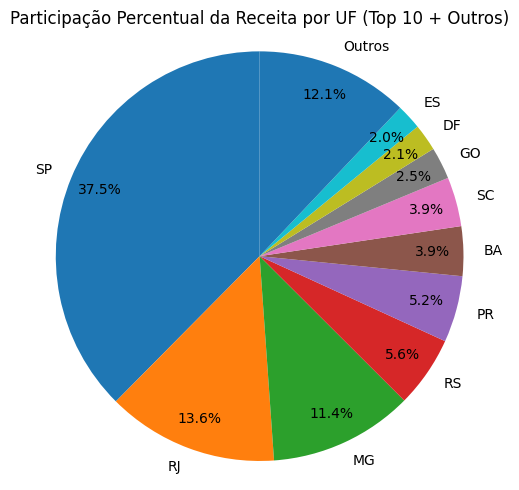

In [64]:
# Participação % da Receita por UF
import matplotlib.pyplot as plt
import seaborn as sns

uf_metrics['revenue_share_%'] = (
    uf_metrics['payment_value'] / uf_metrics['payment_value'].sum()
) * 100

# Exibir a tabela original
print("Participação Percentual da Receita por UF (Tabela Completa)")


# 'Others' - 11 item em diante
data_for_pie_revenue = uf_metrics.sort_values(by='revenue_share_%', ascending=False).reset_index(drop=True)

# Top 10 estados
top_10_states_revenue = data_for_pie_revenue.head(10)

# Soma dos demais como 'Others'
others_share_revenue = data_for_pie_revenue.iloc[10:]['revenue_share_%'].sum()

# Criar DataFrame para o gráfico de pizza
pie_data_revenue = top_10_states_revenue[['customer_state', 'revenue_share_%']].copy()
pie_data_revenue.loc[len(pie_data_revenue)] = ['Outros', others_share_revenue]

# Criar o gráfico de pizza
plt.figure(figsize=(5, 5))
plt.pie(
    pie_data_revenue['revenue_share_%'],
    labels=pie_data_revenue['customer_state'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
plt.title('Participação Percentual da Receita por UF (Top 10 + Outros)')
plt.axis('equal')  # Garante que o gráfico de pizza seja um círculo.
plt.tight_layout()
plt.show()

Participação Percentual dos Pedidos por UF (Tabela Completa)


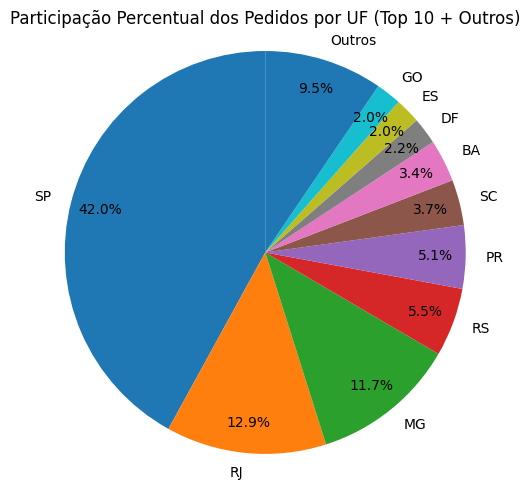

In [65]:
# Participação % dos Pedidos por UF
import matplotlib.pyplot as plt
import seaborn as sns

uf_metrics['orders_share_%'] = (
    uf_metrics['orders'] / uf_metrics['orders'].sum()
) * 100

# Exibir a tabela original
print("Participação Percentual dos Pedidos por UF (Tabela Completa)")

# Agrupar do 11º item em diante como 'Others'
data_for_pie = uf_metrics.sort_values(by='orders_share_%', ascending=False).reset_index(drop=True)

# Top 10 estados
top_10_states = data_for_pie.head(10)

# Soma dos demais como 'Others'
others_share = data_for_pie.iloc[10:]['orders_share_%'].sum()

# DataFrame para o gráfico
pie_data = top_10_states[['customer_state', 'orders_share_%']].copy()
pie_data.loc[len(pie_data)] = ['Outros', others_share]

# Gráfico de pizza
plt.figure(figsize=(5, 5))
plt.pie(
    pie_data['orders_share_%'],
    labels=pie_data['customer_state'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
plt.title('Participação Percentual dos Pedidos por UF (Top 10 + Outros)')
plt.axis('equal')  # Garante que o gráfico de pizza seja um círculo.
plt.tight_layout()
plt.show()

In [66]:
# Receita, Pedidos e Ticket Médio por Seller

seller_metrics = df_items_agg.groupby('seller_id').agg({
    'payment_sum': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'orders'}).reset_index()

seller_metrics['ticket_medio'] = seller_metrics['payment_sum'] / seller_metrics['orders']

display(seller_metrics)




,seller_id,payment_sum,orders,ticket_medio
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,916.020000
1,001cca7ae9ae17fb1caed9dfb1094831,48349.22,200,241.746100
2,001e6ad469a905060d959994f1b41e4f,267.94,1,267.940000
3,002100f778ceb8431b7a1020ff7ab48f,2478.33,51,48.594706
4,004c9cd9d87a3c30c522c48c4fc07416,25925.58,147,176.364490
...,...,...,...,...
3028,ffcfefa19b08742c5d315f2791395ee5,79.52,1,79.520000
3029,ffdd9f82b9a447f6f8d4b91554cc7dd3,3607.52,18,200.417778
3030,ffeee66ac5d5a62fe688b9d26f83f534,2259.55,14,161.396429
3031,fffd5413c0700ac820c7069d66d98c89,12834.27,60,213.904500


In [67]:
# Representatividade de cada vendedor
seller_metrics['revenue_share_%'] = (
    seller_metrics['payment_sum'] / seller_metrics['payment_sum'].sum()
) * 100

seller_metrics['orders_share_%'] = (
    seller_metrics['orders'] / seller_metrics['orders'].sum()
) * 100

display(seller_metrics)

,seller_id,payment_sum,orders,ticket_medio,revenue_share_%,orders_share_%
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,916.020000,0.013634,0.003044
1,001cca7ae9ae17fb1caed9dfb1094831,48349.22,200,241.746100,0.239868,0.202901
2,001e6ad469a905060d959994f1b41e4f,267.94,1,267.940000,0.001329,0.001015
3,002100f778ceb8431b7a1020ff7ab48f,2478.33,51,48.594706,0.012295,0.051740
4,004c9cd9d87a3c30c522c48c4fc07416,25925.58,147,176.364490,0.128621,0.149133
...,...,...,...,...,...,...
3028,ffcfefa19b08742c5d315f2791395ee5,79.52,1,79.520000,0.000395,0.001015
3029,ffdd9f82b9a447f6f8d4b91554cc7dd3,3607.52,18,200.417778,0.017897,0.018261
3030,ffeee66ac5d5a62fe688b9d26f83f534,2259.55,14,161.396429,0.011210,0.014203
3031,fffd5413c0700ac820c7069d66d98c89,12834.27,60,213.904500,0.063673,0.060870


In [68]:
# Pareto / Seller

seller_metrics = seller_metrics.sort_values(by='payment_sum', ascending=False)

seller_metrics['cum_revenue_%'] = (
    seller_metrics['payment_sum'].cumsum() / seller_metrics['payment_sum'].sum()
) * 100

seller_metrics['cum_sellers_%'] = (
    (seller_metrics.index + 1) / len(seller_metrics)
) * 100

display(seller_metrics)

,seller_id,payment_sum,orders,ticket_medio,revenue_share_%,orders_share_%,cum_revenue_%,cum_sellers_%
1502,7c67e1448b00f6e969d365cea6b010ab,512645.19,982,522.041945,2.543311,0.996246,2.543311,49.554896
189,1025f0e2d44d7041d6cf58b6550e0bfa,312456.49,915,341.482503,1.550144,0.928274,4.093456,6.264425
865,4a3ca9315b744ce9f8e9374361493884,306138.80,1806,169.512071,1.518801,1.832200,5.612257,28.552588
360,1f50f920176fa81dab994f9023523100,291918.98,1404,207.919501,1.448255,1.424368,7.060512,11.902407
995,53243585a1d6dc2643021fd1853d8905,284903.08,358,795.818659,1.413448,0.363194,8.473959,32.838773
...,...,...,...,...,...,...,...,...
681,3ac588cd562971392504a9e17130c40b,19.29,1,19.290000,0.000096,0.001015,99.999687,22.485987
2045,ad14615bdd492b01b0d97922e87cb87f,19.21,1,19.210000,0.000095,0.001015,99.999783,67.457962
853,4965a7002cca77301c82d3f91b82e1a9,16.36,1,16.360000,0.000081,0.001015,99.999864,28.156940
1434,77128dec4bec4878c37ab7d6169d6f26,15.22,1,15.220000,0.000076,0.001015,99.999939,47.312892


In [69]:
# Receita por Categoria


category_metrics = df_items_agg.groupby('product_category_name_english').agg({
    'payment_sum': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'orders'}).reset_index()

category_metrics['ticket_medio'] = (
    category_metrics['payment_sum'] / category_metrics['orders']
)

display(category_metrics)





,product_category_name_english,payment_sum,orders,ticket_medio
0,agro_industry_and_commerce,118730.61,182,652.365989
1,air_conditioning,91170.66,253,360.358340
2,art,30992.93,202,153.430347
3,arts_and_craftmanship,2326.17,23,101.137826
4,audio,60388.62,350,172.538914
...,...,...,...,...
66,stationery,318105.09,2311,137.648243
67,tablets_printing_image,10042.93,79,127.125696
68,telephony,487189.71,4199,116.025175
69,toys,619975.71,3886,159.540841


In [70]:
# Participação por Categoria (Top 5 e Bottom 5 por Share)

# Calcular participação
category_metrics['revenue_share_%'] = (
    category_metrics['payment_sum'] / category_metrics['payment_sum'].sum()
) * 100

#  Top 5
top5 = category_metrics.sort_values(
    by='revenue_share_%',
    ascending=False
).head(5)

#  Bottom 5
bottom5 = category_metrics.sort_values(
    by='revenue_share_%',
    ascending=True
).head(5)

# Exibir resultados
print("\n Top 5 Categorias por Participação de Receita")
display(top5[['product_category_name_english', 'payment_sum', 'revenue_share_%']])

print("\n Bottom 5 Categorias por Participação de Receita")
display(bottom5[['product_category_name_english', 'payment_sum', 'revenue_share_%']])



 Top 5 Categorias por Participação de Receita


,product_category_name_english,payment_sum,revenue_share_%
7,bed_bath_table,1743998.80,8.652245
43,health_beauty,1662963.59,8.250217
15,computers_accessories,1599481.06,7.935270
39,furniture_decor,1443963.61,7.163724
70,watches_gifts,1430553.48,7.097195



 Bottom 5 Categorias por Participação de Receita


,product_category_name_english,payment_sum,revenue_share_%
61,security_and_services,324.51,0.001610
29,fashion_childrens_clothes,785.67,0.003898
11,cds_dvds_musicals,1199.43,0.005951
46,home_comfort_2,1710.54,0.008486
35,flowers,2213.01,0.010979


In [71]:
# Categoria por Mês

df_items_agg['order_purchase_timestamp'] = pd.to_datetime(df_items_agg['order_purchase_timestamp'])
df_items_agg['year_month'] = df_items_agg['order_purchase_timestamp'].dt.to_period('M')

category_month = df_items_agg.groupby(
    ['year_month', 'product_category_name_english']
).agg({
    'payment_sum': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'orders'}).reset_index()



display(category_month)

,year_month,product_category_name_english,payment_sum,orders
0,2016-09,furniture_decor,272.46,1
1,2016-09,health_beauty,0.00,1
2,2016-09,telephony,75.06,1
3,2016-10,air_conditioning,4675.43,5
4,2016-10,audio,183.03,2
...,...,...,...,...
1248,2018-08,stationery,20666.86,159
1249,2018-08,telephony,68240.47,246
1250,2018-08,toys,27884.78,155
1251,2018-08,watches_gifts,85215.66,392


In [72]:
#Top 5 categorias com maior ticket e maior volume

# Normalização (0 a 1)
category_metrics['ticket_norm'] = (
    category_metrics['ticket_medio'] / category_metrics['ticket_medio'].max()
)

category_metrics['orders_norm'] = (
    category_metrics['orders'] / category_metrics['orders'].max()
)

# Score combinado
category_metrics['score'] = (
    0.5 * category_metrics['ticket_norm'] +
    0.5 * category_metrics['orders_norm']
)

# Top 5
category_top5 = category_metrics.sort_values(
    by='score',
    ascending=False
).head(5)

print("\n Top 5 Categorias (Score Ticket + Volume)")
display(category_top5[
    ['product_category_name_english', 'ticket_medio', 'orders', 'score']
])

# Bottom 5
category_bottom5 = category_metrics.sort_values(
    by='score',
    ascending=True
).head(5)

print("\n Bottom 5 Categorias (Score Ticket + Volume)")
display(category_bottom5[
    ['product_category_name_english', 'ticket_medio', 'orders', 'score']
])


 Top 5 Categorias (Score Ticket + Volume)


,product_category_name_english,ticket_medio,orders,score
7,bed_bath_table,185.196857,9417,0.560047
43,health_beauty,188.203213,8836,0.530173
14,computers,1542.108011,181,0.509610
65,sports_leisure,181.376045,7720,0.468705
15,computers_accessories,239.121103,6689,0.432686



 Bottom 5 Categorias (Score Ticket + Volume)


,product_category_name_english,ticket_medio,orders,score
46,home_comfort_2,71.272500,24,0.024383
35,flowers,76.310690,29,0.026282
29,fashion_childrens_clothes,98.208750,8,0.032267
11,cds_dvds_musicals,99.952500,12,0.033045
3,arts_and_craftmanship,101.137826,23,0.034013


In [73]:
# Clientes Recorrentes

customer_orders = df_orders_agg.groupby('customer_unique_id').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

customer_orders['is_recorrente'] = customer_orders['order_id'] > 1

display(customer_orders)

,customer_unique_id,order_id,payment_value,is_recorrente
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,False
2,0000f46a3911fa3c0805444483337064,1,86.22,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,False
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,False
...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,1,4134.84,False
96092,fffea47cd6d3cc0a88bd621562a9d061,1,84.58,False
96093,ffff371b4d645b6ecea244b27531430a,1,112.46,False
96094,ffff5962728ec6157033ef9805bacc48,1,133.69,False


In [74]:
# % Clientes Recorrentes

repeat_rate = customer_orders['is_recorrente'].mean() * 100

display (repeat_rate)

np.float64(3.1187562437562435)

In [75]:
# Itens por Pedido por Mês

items_month = df_orders_agg.groupby('year_month').agg({
    'items_count': 'mean'
}).reset_index()

display(items_month)


,year_month,items_count
0,2016-09,1.500000
1,2016-10,1.188272
2,2016-12,1.000000
3,2017-01,1.278750
4,2017-02,1.164607
5,2017-03,1.193512
6,2017-04,1.191348
7,2017-05,1.201351
8,2017-06,1.177812
9,2017-07,1.213860


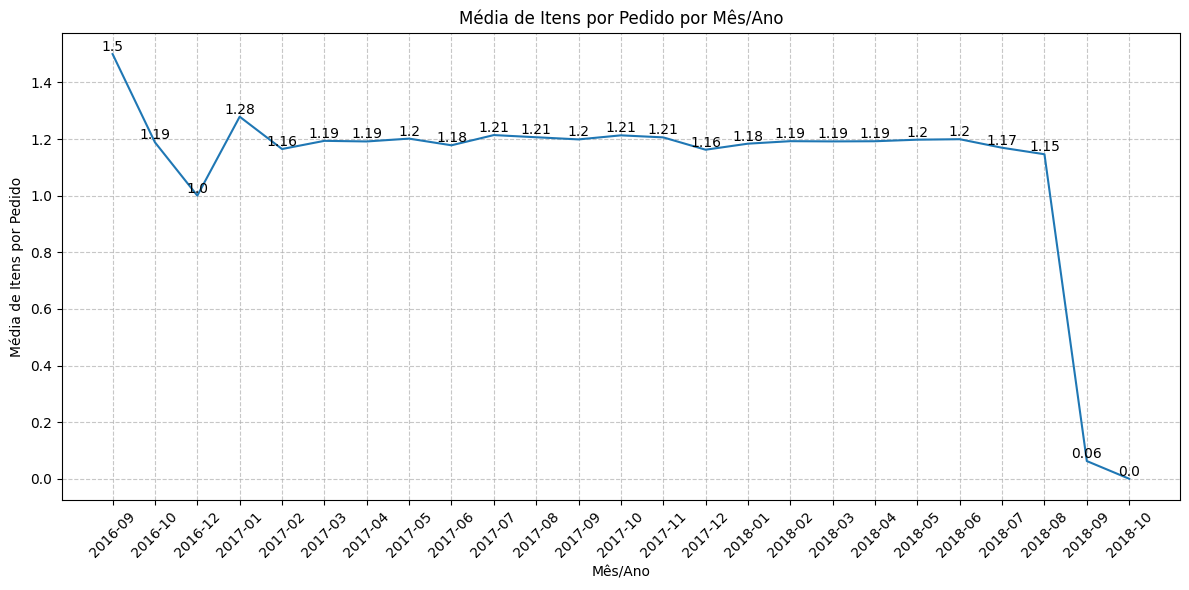

'Média geral de itens por pedido: 1.11'

In [76]:
# Gráfico com Média de Itens por Pedido (Mensal)

import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'year_month' to string for plotting compatibility
items_month['year_month'] = items_month['year_month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(x='year_month', y='items_count', data=items_month)
plt.title('Média de Itens por Pedido por Mês/Ano')
plt.xlabel('Mês/Ano')
plt.ylabel('Média de Itens por Pedido')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Adicionar os valores sobre a linha
for index, row in items_month.iterrows():
    plt.text(row['year_month'], row['items_count'], round(row['items_count'], 2), color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

overall_avg_items_per_order = items_month['items_count'].mean()
display(f"Média geral de itens por pedido: {overall_avg_items_per_order:.2f}")



In [77]:
# Variação Média da quantidade de itens

# Ajusta 'year_month' como datetime
items_month_for_variation = df_orders_agg.groupby('year_month').agg({
    'items_count': 'mean'
}).reset_index()
items_month_for_variation['year_month'] = items_month_for_variation['year_month'].dt.to_timestamp()

# Ordena por data
items_month_for_variation = items_month_for_variation.sort_values(by='year_month').reset_index(drop=True)

# Calcula a variação percentual mês a mês
items_month_for_variation['mom_variation_%'] = items_month_for_variation['items_count'].pct_change() * 100

# Remove o primeiro valor NaN da variação (não há mês anterior para comparar)
items_month_for_variation = items_month_for_variation.dropna(subset=['mom_variation_%'])

# Divide os dados em primeiros 12 meses e meses subsequentes
first_12_months = items_month_for_variation.head(12)
subsequent_months = items_month_for_variation.iloc[12:]

# Calcula a média da variação para cada período
avg_variation_first_12 = first_12_months['mom_variation_%'].mean()
avg_variation_subsequent = subsequent_months['mom_variation_%'].mean()

print(f"Média da variação mensal de itens por pedido (Primeiros 12 meses): {avg_variation_first_12:.2f}%")
print(f"Média da variação mensal de itens por pedido (Meses subsequentes): {avg_variation_subsequent:.2f}%")


Média da variação mensal de itens por pedido (Primeiros 12 meses): -1.13%
Média da variação mensal de itens por pedido (Meses subsequentes): -16.67%


In [78]:
# Concentração Top 10 Sellers

top10 = seller_metrics.head(10)

top10_share = top10['payment_sum'].sum() / seller_metrics['payment_sum'].sum() * 100

display("Top 10 Sellers")
display(top10[['seller_id', 'payment_sum']])

display(f"Top 10 Sellers concentram: {top10_share:.2f}% da receita")

'Top 10 Sellers'

,seller_id,payment_sum
1502,7c67e1448b00f6e969d365cea6b010ab,512645.19
189,1025f0e2d44d7041d6cf58b6550e0bfa,312456.49
865,4a3ca9315b744ce9f8e9374361493884,306138.80
360,1f50f920176fa81dab994f9023523100,291918.98
995,53243585a1d6dc2643021fd1853d8905,284903.08
2589,da8622b14eb17ae2831f4ac5b9dab84a,276578.63
841,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
1787,955fee9216a65b617aa5c0531780ce60,236414.48
2963,fa1c13f2614d7b5c4749cbc52fecda94,206513.23
1527,7e93a43ef30c4f03f38b393420bc753a,185134.21


'Top 10 Sellers concentram: 14.27% da receita'

In [79]:
# Receita por UF vs Ticket Médio

uf_sorted = uf_metrics.sort_values(by='ticket_medio', ascending=False)

display("UF por Ticket Médio (alto → baixo)")
display(uf_sorted[['customer_state', 'payment_value', 'orders', 'ticket_medio']].head(10))

'UF por Ticket Médio (alto → baixo)'

,customer_state,payment_value,orders,ticket_medio
14,PB,181660.73,536,338.92
3,AP,21642.70,68,318.28
0,AC,24984.86,81,308.46
12,MT,257802.26,907,284.24
16,PI,137158.89,495,277.09
20,RO,69184.48,253,273.46
1,AL,112296.47,413,271.90
21,RR,12462.21,46,270.92
13,PA,263217.70,975,269.97
9,MA,200363.24,747,268.22


In [80]:
# Categorias com Alto Ticket e Baixo Volume

category_sorted = category_metrics.sort_values(by='ticket_medio', ascending=False)

display(" Categorias com maior Ticket Médio")
display(category_sorted[['product_category_name_english', 'payment_sum', 'orders', 'ticket_medio']])

' Categorias com maior Ticket Médio'

,product_category_name_english,payment_sum,orders,ticket_medio
14,computers,279121.55,181,1542.108011
34,fixed_telephony,207071.05,217,954.244470
64,small_appliances_home_oven_and_coffee,51229.32,75,683.057600
0,agro_industry_and_commerce,118730.61,182,652.365989
45,home_appliances_2,124865.92,234,533.615043
...,...,...,...,...
11,cds_dvds_musicals,1199.43,12,99.952500
29,fashion_childrens_clothes,785.67,8,98.208750
10,books_technical,24992.85,260,96.126346
35,flowers,2213.01,29,76.310690


In [81]:
# Receita vs Avaliação (categoria)

# Agregação
category_review = df_items_agg.groupby('product_category_name_english').agg({
    'payment_sum': 'sum',
    'review_mean': 'mean'
}).reset_index()

#  Top 5 por Receita
top5 = category_review.sort_values(
    by='payment_sum',
    ascending=False
).head(5)

#  Bottom 5 por Receita
bottom5 = category_review.sort_values(
    by='payment_sum',
    ascending=True
).head(5)

# Exibir
print(" Top 5 Categorias por Receita")
display(top5)

print(" Bottom 5 Categorias por Receita")
display(bottom5)

 Top 5 Categorias por Receita


,product_category_name_english,payment_sum,review_mean
7,bed_bath_table,1743998.80,3.944001
43,health_beauty,1662963.59,4.178488
15,computers_accessories,1599481.06,4.009744
39,furniture_decor,1443963.61,3.996989
70,watches_gifts,1430553.48,4.055417


 Bottom 5 Categorias por Receita


,product_category_name_english,payment_sum,review_mean
61,security_and_services,324.51,2.500000
29,fashion_childrens_clothes,785.67,4.500000
11,cds_dvds_musicals,1199.43,4.666667
46,home_comfort_2,1710.54,3.826087
35,flowers,2213.01,4.392857


In [82]:
# Oportunidades (Baixa Receita / Alta Avaliação)

low_revenue_high_rating = category_review[
    (category_review['review_mean'] >= 4) &  # alta avaliação
    (category_review['payment_sum'] < category_review['payment_sum'].median())  # baixa receita
]

# Top 10 dentro desse grupo (ordenado por avaliação)
top10_opportunity = low_revenue_high_rating.sort_values(
    by=['review_mean', 'payment_sum'],
    ascending=[False, False]
).head(10)

print(" Top 10 Categorias: Baixa Receita + Alta Avaliação (Oportunidade)")
display(top10_opportunity[
    ['product_category_name_english', 'payment_sum', 'review_mean']
])


 Top 10 Categorias: Baixa Receita + Alta Avaliação (Oportunidade)


,product_category_name_english,payment_sum,review_mean
11,cds_dvds_musicals,1199.43,4.666667
29,fashion_childrens_clothes,785.67,4.500000
8,books_general_interest,64694.76,4.462598
22,costruction_tools_tools,21069.07,4.425532
10,books_technical,24992.85,4.400778
35,flowers,2213.01,4.392857
37,food_drink,27474.43,4.382743
9,books_imported,6701.89,4.320755
64,small_appliances_home_oven_and_coffee,51229.32,4.293333
36,food,46428.67,4.275785


In [83]:
# Média de Itens e Receita por Pedido

# Calcula a média de 'items_count' por pedido
mean_items_per_order = df_orders_agg['items_count'].mean()

# Calcula a receita média por pedido
mean_revenue_per_order = df_orders_agg['payment_value'].mean()

display(f"Média de itens por pedido: {mean_items_per_order:.2f}")
display(f"Receita média por pedido: R$ {mean_revenue_per_order:.2f}")

'Média de itens por pedido: 1.19'

'Receita média por pedido: R$ 206.95'

In [84]:
# Relação Itens vs Receita

items_vs_revenue = df_orders_agg.groupby('items_count').agg({
    'payment_value': 'mean',
    'order_id': 'count'
}).reset_index().rename(columns={
    'order_id': 'num_orders'
})

display(items_vs_revenue)

,items_count,payment_value,num_orders
0,0,210.092219,775
1,1,150.761480,85747
2,2,358.860417,9819
3,3,750.825434,1557
4,4,1076.951564,831
5,5,1910.007189,249
6,6,2355.387036,280
7,7,2067.890000,47
8,8,4898.018000,40
9,9,2591.953846,13


In [85]:
# Crescimento de Payment e Orders

import numpy as np

category_month = category_month.rename(
    columns={'product_category_name_english': 'product_category'}
)

# Ordenar por categoria e mês
category_month = category_month.sort_values(
    ['product_category', 'year_month']
)

# Calcular MoM
category_month['growth_payment'] = (
    category_month.groupby('product_category')['payment_sum']
    .pct_change()
)

category_month['growth_orders'] = (
    category_month.groupby('product_category')['orders']
    .pct_change()
)

# Tratar valores nulos (resultantes de primeiro mês ou sem alteração) e infinitos
category_month[['growth_payment', 'growth_orders']] = (
    category_month[['growth_payment', 'growth_orders']]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Agregar por categoria
category_result = category_month.groupby('product_category').agg({
    'payment_sum': 'sum',
    'orders': 'sum',
    'growth_payment': 'mean',
    'growth_orders': 'mean'
}).reset_index()

category_growth = category_result.copy()

category_growth['ticket_medio'] = np.where(
    category_growth['orders'] != 0,
    category_growth['payment_sum'] / category_growth['orders'],
    0
)

display(category_growth)

# Filtrar 'inf' e 'NaN' para exibição dos Top/Bottom
filtered_growth = category_growth.replace([np.inf, -np.inf], np.nan).dropna(subset=['growth_payment', 'growth_orders'])

# Top 5 Growth Payment
print("\nTop 5 Categorias por Crescimento de Receita (growth_payment):")
display(filtered_growth.sort_values(by='growth_payment', ascending=False).head(5)[['product_category', 'growth_payment']])

# Bottom 5 Growth Payment
print("\nBottom 5 Categorias por Crescimento de Receita (growth_payment):")
display(filtered_growth.sort_values(by='growth_payment', ascending=True).head(5)[['product_category', 'growth_payment']])

# Top 5 Growth Orders
print("\nTop 5 Categorias por Crescimento de Pedidos (growth_orders):")
display(filtered_growth.sort_values(by='growth_orders', ascending=False).head(5)[['product_category', 'growth_orders']])

# Bottom 5 Growth Orders
print("\nBottom 5 Categorias por Crescimento de Pedidos (growth_orders):")
display(filtered_growth.sort_values(by='growth_orders', ascending=True).head(5)[['product_category', 'growth_orders']])

,product_category,payment_sum,orders,growth_payment,growth_orders,ticket_medio
0,agro_industry_and_commerce,118730.61,182,1.529850,0.422698,652.365989
1,air_conditioning,91170.66,253,0.920154,0.491314,360.358340
2,art,30992.93,202,3.550796,0.769861,153.430347
3,arts_and_craftmanship,2326.17,23,1.717009,1.483333,101.137826
4,audio,60388.62,350,0.484217,0.309203,172.538914
...,...,...,...,...,...,...
66,stationery,318105.09,2311,0.199981,0.310763,137.648243
67,tablets_printing_image,10042.93,79,0.324481,0.376074,127.125696
68,telephony,487189.71,4199,0.813681,0.665638,116.025175
69,toys,619975.71,3886,0.161948,0.160767,159.540841



Top 5 Categorias por Crescimento de Receita (growth_payment):


,product_category,growth_payment
19,construction_tools_safety,8.473152
28,fashion_bags_accessories,6.288954
2,art,3.550796
25,dvds_blu_ray,2.952494
58,party_supplies,2.746706



Bottom 5 Categorias por Crescimento de Receita (growth_payment):


,product_category,growth_payment
61,security_and_services,-0.223883
16,consoles_games,0.120975
59,perfumery,0.127869
69,toys,0.161948
66,stationery,0.199981



Top 5 Categorias por Crescimento de Pedidos (growth_orders):


,product_category,growth_orders
39,furniture_decor,2.443715
14,computers,2.204543
43,health_beauty,2.125681
3,arts_and_craftmanship,1.483333
28,fashion_bags_accessories,1.399720



Bottom 5 Categorias por Crescimento de Pedidos (growth_orders):


,product_category,growth_orders
61,security_and_services,0.000000
11,cds_dvds_musicals,0.055556
29,fashion_childrens_clothes,0.071429
54,market_place,0.114904
59,perfumery,0.133324


In [86]:
# Novos vs Recorrentes (Colume de Pedidos)

# Adiciona a coluna 'is_recorrente' de customer_orders ao df_orders_agg
df_orders_agg_with_recurrence = df_orders_agg.merge(
    customer_orders[['customer_unique_id', 'is_recorrente']],
    on='customer_unique_id',
    how='left'
)

recorrencia_orders = df_orders_agg_with_recurrence.groupby('is_recorrente').agg({
    'order_id': 'count'
}).reset_index()

print ("Clientes Novos vs Recorrentes")
display(recorrencia_orders)

Clientes Novos vs Recorrentes


,is_recorrente,order_id
0,False,93099
1,True,6342


In [87]:
# Variação Mensal da quantidade de pedidos por State

df_orders_agg['order_purchase_timestamp'] = pd.to_datetime(df_orders_agg['order_purchase_timestamp'])
df_orders_agg['year_month'] = df_orders_agg['order_purchase_timestamp'].dt.to_period('M')

# Agrega orders por UF e Mês
ord_uf_month = df_orders_agg.groupby(['customer_state', 'year_month']).agg(
    orders=('order_id', 'nunique')
).reset_index()

# Ordena
ord_uf_month = ord_uf_month.sort_values(by=['customer_state', 'year_month'])

# Calcula a variação percentual
ord_uf_month['mom_variation_orders'] = ord_uf_month.groupby('customer_state')['orders'].pct_change() * 100

print ("Variação Mensal da quantidade de pedidos por State")
display(ord_uf_month[['customer_state', 'year_month', 'orders', 'mom_variation_orders']])

Variação Mensal da quantidade de pedidos por State


,customer_state,year_month,orders,mom_variation_orders
0,AC,2017-01,2,NaN
1,AC,2017-02,3,50.000000
2,AC,2017-03,2,-33.333333
3,AC,2017-04,5,150.000000
4,AC,2017-05,8,60.000000
...,...,...,...,...
560,TO,2018-04,19,-5.000000
561,TO,2018-05,16,-15.789474
562,TO,2018-06,18,12.500000
563,TO,2018-07,22,22.222222


In [88]:
# Variação Média e Mediana mensal de pedidos por UF


state_variation_stats = ord_uf_month.groupby('customer_state').agg(
    mean_mom_variation_orders=('mom_variation_orders', 'mean'),
    median_mom_variation_orders=('mom_variation_orders', 'median')
).reset_index()

# Renomeia as colunas conforme solicitado
state_variation_stats = state_variation_stats.rename(columns={
    'mean_mom_variation_orders': '% de var. média',
    'median_mom_variation_orders': '% de var. mediana'
})

print ("Média e Mediana da variação mensal")
#display(state_variation_stats)

# Top 5 estados por Variação Média Mensal de Pedidos
print("Top 5 UFs por % de variação média de pedidos:")
display(state_variation_stats.sort_values(by='% de var. média', ascending=False).head(5).reset_index(drop=True))

# Bottom 5 estados por Variação Média Mensal de Pedidos
print("Bottom 5 UFs por % de variação média de pedidos:")
display(state_variation_stats.sort_values(by='% de var. média', ascending=True).head(5).reset_index(drop=True))

# Top 5 estados por Variação Mediana Mensal de Pedidos
print("Top 5 UFs por % de variação mediana de pedidos:")
display(state_variation_stats.sort_values(by='% de var. mediana', ascending=False).head(5).reset_index(drop=True))

# Bottom 5 estados por Variação Mediana Mensal de Pedidos
print("Bottom 5 UFs por % de variação mediana de pedidos:")
display(state_variation_stats.sort_values(by='% de var. mediana', ascending=True).head(5).reset_index(drop=True))


Média e Mediana da variação mensal
Top 5 UFs por % de variação média de pedidos:


,customer_state,% de var. média,% de var. mediana
0,PR,312.396520,4.062500
1,SP,255.292197,7.793017
2,RS,127.411694,6.250000
3,TO,86.365654,13.333333
4,MS,64.307544,0.000000


Bottom 5 UFs por % de variação média de pedidos:


,customer_state,% de var. média,% de var. mediana
0,RJ,10.129966,1.693573
1,AC,13.421053,20.000000
2,CE,15.280152,11.237374
3,MG,17.220664,7.598784
4,SC,18.190538,-1.886792


Top 5 UFs por % de variação mediana de pedidos:


,customer_state,% de var. média,% de var. mediana
0,AC,13.421053,20.000000
1,AP,34.500891,20.000000
2,TO,86.365654,13.333333
3,PB,39.095137,12.165899
4,CE,15.280152,11.237374


Bottom 5 UFs por % de variação mediana de pedidos:


,customer_state,% de var. média,% de var. mediana
0,AM,42.725885,-11.111111
1,SC,18.190538,-1.886792
2,RR,41.372549,0.000000
3,MS,64.307544,0.000000
4,SE,26.743889,0.000000


In [89]:
# Payment por Mês por State

# Agrega receita por UF e Mês
rev_uf_month = df_orders_agg.groupby(['customer_state', 'year_month']).agg(
    revenue=('payment_value', 'sum')
).reset_index()

# Ordena
rev_uf_month = rev_uf_month.sort_values(by=['customer_state', 'year_month'])

# Calcula a variação percentual
rev_uf_month['mom_variation_revenue'] = rev_uf_month.groupby('customer_state')['revenue'].pct_change() * 100

display(rev_uf_month[['customer_state', 'year_month', 'revenue', 'mom_variation_revenue']])

,customer_state,year_month,revenue,mom_variation_revenue
0,AC,2017-01,1657.33,NaN
1,AC,2017-02,1289.08,-22.219473
2,AC,2017-03,530.18,-58.871443
3,AC,2017-04,1351.51,154.915312
4,AC,2017-05,2382.64,76.294663
...,...,...,...,...
560,TO,2018-04,6383.31,11.993986
561,TO,2018-05,3314.33,-48.078191
562,TO,2018-06,7143.26,115.526517
563,TO,2018-07,4309.21,-39.674462


In [90]:
# Variação Média Mensal de Receita por Estado

# Calcula a média da variação mensal de receita por UF
mean_revenue_variation_per_state = rev_uf_month.groupby('customer_state').agg(
    mean_mom_variation_revenue=('mom_variation_revenue', 'mean')
).reset_index()

# Renomeia a coluna para melhor clareza
mean_revenue_variation_per_state = mean_revenue_variation_per_state.rename(columns={
    'mean_mom_variation_revenue': '% de var. média de receita'
})

print("Variação Média Mensal de Receita por Estado:")
display(mean_revenue_variation_per_state)

Variação Média Mensal de Receita por Estado:


,customer_state,% de var. média de receita
0,AC,61.889356
1,AL,70.358173
2,AM,146.275136
3,AP,59.305646
4,BA,36.969000
5,CE,25.374728
6,DF,30.341865
7,ES,33.790542
8,GO,105.860783
9,MA,25.857594


In [91]:
# Variação média e mediana mensal de receita por UF


revenue_variation_stats = rev_uf_month.groupby('customer_state').agg(
    mean_mom_variation_revenue=('mom_variation_revenue', 'mean'),
    median_mom_variation_revenue=('mom_variation_revenue', 'median')
).reset_index()

# Renomeia as colunas para melhor clareza
revenue_variation_stats = revenue_variation_stats.rename(columns={
    'mean_mom_variation_revenue': '% de var. média',
    'median_mom_variation_revenue': '% de var. mediana'
})

print("Média e Mediana da Variação Mensal de Receita por Estado:")
display(revenue_variation_stats)

# Top 5 estados por Variação Média Mensal de Receita
print("Top 5 UFs por % de variação média de receita:")
display(revenue_variation_stats.sort_values(by='% de var. média', ascending=False).head(5).reset_index(drop=True))

# Bottom 5 estados por Variação Média Mensal de Receita
print("Bottom 5 UFs por % de variação média de receita:")
display(revenue_variation_stats.sort_values(by='% de var. média', ascending=True).head(5).reset_index(drop=True))

# Top 5 estados por Variação Mediana Mensal de Receita
print("Top 5 UFs por % de variação mediana de receita:")
display(revenue_variation_stats.sort_values(by='% de var. mediana', ascending=False).head(5).reset_index(drop=True))

# Bottom 5 estados por Variação Mediana Mensal de Receita
print("Bottom 5 UFs por % de variação mediana de receita:")
display(revenue_variation_stats.sort_values(by='% de var. mediana', ascending=True).head(5).reset_index(drop=True))

Média e Mediana da Variação Mensal de Receita por Estado:


,customer_state,% de var. média,% de var. mediana
0,AC,61.889356,-3.596425
1,AL,70.358173,10.779992
2,AM,146.275136,3.320540
3,AP,59.305646,-20.325086
4,BA,36.969000,10.006224
5,CE,25.374728,6.423235
6,DF,30.341865,4.538054
7,ES,33.790542,2.127536
8,GO,105.860783,7.121782
9,MA,25.857594,7.107740


Top 5 UFs por % de variação média de receita:


,customer_state,% de var. média,% de var. mediana
0,SP,2162.251695,12.954054
1,PR,1984.343937,2.853256
2,RS,369.033518,15.481568
3,MS,256.269600,2.897218
4,RR,176.279765,28.445028


Bottom 5 UFs por % de variação média de receita:


,customer_state,% de var. média,% de var. mediana
0,RJ,10.837671,0.535724
1,MG,19.267684,2.741594
2,SC,22.109806,0.124649
3,PA,25.138700,6.015042
4,CE,25.374728,6.423235


Top 5 UFs por % de variação mediana de receita:


,customer_state,% de var. média,% de var. mediana
0,RR,176.279765,28.445028
1,PB,74.493937,26.957574
2,TO,127.102123,21.471981
3,MT,27.125564,16.441194
4,RS,369.033518,15.481568


Bottom 5 UFs por % de variação mediana de receita:


,customer_state,% de var. média,% de var. mediana
0,AP,59.305646,-20.325086
1,SE,76.948285,-7.238545
2,RN,28.856489,-6.477286
3,AC,61.889356,-3.596425
4,RO,40.919951,-2.686216
